🔹 АНАЛИТИЧЕСКОЕ РЕШЕНИЕ МЕТОДОМ ЛАГРАНЖА

📐 Функция Лагранжа:
L = lambda1*(x1**2 + x2**2 - 5) - lambda2*x1 - lambda3*x2 + x1*x2 + (x1 - 2)**2 + (x2 - 3)**2

📐 Условия стационарности:
∂L/∂x1 = 2*lambda1*x1 - lambda2 + 2*x1 + x2 - 4 = 0
∂L/∂x2 = 2*lambda1*x2 - lambda3 + x1 + 2*x2 - 6 = 0

🔎 Перебор активных ограничений...

--- Случай: все ограничения неактивны ---
Стационарные точки: [{x1: 2/3, x2: 8/3}]

  Проверка: x₁=0.6667, x₂=2.6667
  ❌ g1: circle: 2.5556 > 0
  ✅ g2: x1>=0: -0.6667 ≤ 0
  ✅ g3: x2>=0: -2.6667 ≤ 0

🔹 ЧИСЛЕННАЯ ПРОВЕРКА И ГРАФИКИ


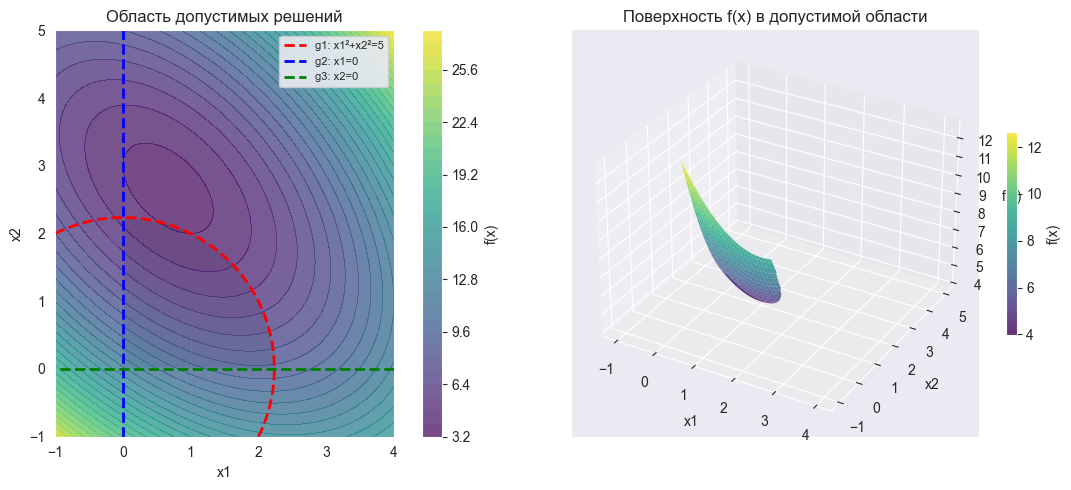


✅ Численный минимум (SLSQP):
   x* = (0.761591, 2.102375)
   f(x*) = 3.940538
   Статус: Optimization terminated successfully

--- Численное решение на границе g1=0 ---
📍 Точка минимума: x₁=0.761591, x₂=2.102375
📉 Значение функции: f*=3.940538
🔒 Множитель Лагранжа: λ₁≈0.2458 (проверка: 0.2458)
✅ Условие дополняющей нежёсткости: λ₁·g₁ = 8.20e-08 ≈ 0
✅ Знак λ₁ > 0 → точка является минимумом


In [8]:
# !pip install sympy numpy matplotlib

import sympy as sp
import numpy as np
import matplotlib.pyplot as plt
from mpl_toolkits.mplot3d import Axes3D

# ============================================================
# 🔧 НАСТРОЙКИ ЗАДАЧИ (меняй под свой номер варианта)
# ============================================================

# Переменные
x1, x2 = sp.symbols('x1 x2', real=True)
l0, l1, l2, l3 = sp.symbols('lambda0 lambda1 lambda2 lambda3', real=True)

# Целевая функция (пример: задача 1.1)
f = (x1 - 2)**2 + (x2 - 3)**2 + x1*x2

# Ограничения: список кортежей (выражение, тип, название)
# тип: 'eq' для =0, 'leq' для <=0
constraints = [
    (x1**2 + x2**2 - 5, 'leq', 'g1: circle'),
    (-x1, 'leq', 'g2: x1>=0'),
    (-x2, 'leq', 'g3: x2>=0')
]

# ============================================================
# 🔍 АНАЛИТИЧЕСКОЕ РЕШЕНИЕ (метод Лагранжа)
# ============================================================

print("="*60)
print("🔹 АНАЛИТИЧЕСКОЕ РЕШЕНИЕ МЕТОДОМ ЛАГРАНЖА")
print("="*60)

# Функция Лагранжа (нормируем lambda0 = 1 для нетривиального случая)
L = f  # lambda0 = 1
for i, (g, ctype, name) in enumerate(constraints, start=1):
    lam = sp.symbols(f'lambda{i}', real=True)
    L += lam * g

# Вычисляем градиент по x1, x2
dL_dx1 = sp.diff(L, x1)
dL_dx2 = sp.diff(L, x2)

print(f"\n📐 Функция Лагранжа:\nL = {sp.simplify(L)}")
print(f"\n📐 Условия стационарности:\n∂L/∂x1 = {sp.simplify(dL_dx1)} = 0")
print(f"∂L/∂x2 = {sp.simplify(dL_dx2)} = 0")

# 🔎 Перебор активных ограничений
print("\n🔎 Перебор активных ограничений...")

# Явно объявляем символы множителей (должны совпадать с теми, что в L)
lam1, lam2, lam3 = sp.symbols('lambda1 lambda2 lambda3', real=True)

# === СЛУЧАЙ 1: все ограничения неактивны (λ=0) ===
print("\n--- Случай: все ограничения неактивны ---")

# Подставляем λ=0 в условия стационарности
eq1 = sp.diff(L, x1).subs({lam1: 0, lam2: 0, lam3: 0})
eq2 = sp.diff(L, x2).subs({lam1: 0, lam2: 0, lam3: 0})

# Решаем систему
sol = sp.solve([eq1, eq2], [x1, x2], dict=True)
print(f"Стационарные точки: {sol}")

# Проверка допустимости
for s in sol:
    try:
        x1_val = float(s[x1].evalf())
        x2_val = float(s[x2].evalf())
    except (TypeError, AttributeError, KeyError):
        print(f"  ⚠️ Не удалось оценить точку: {s}")
        continue

    feasible = True
    print(f"\n  Проверка: x₁={x1_val:.4f}, x₂={x2_val:.4f}")

    for g, ctype, name in constraints:
        try:
            val = float(g.subs(s).evalf())
        except:
            print(f"  ⚠️ {name}: не удалось вычислить")
            feasible = False
            continue

        if ctype == 'leq':
            status = "✅" if val <= 1e-6 else "❌"
            print(f"  {status} {name}: {val:.4f} {'≤' if val<=1e-6 else '>'} 0")
            if val > 1e-6:
                feasible = False
        elif ctype == 'eq':
            status = "✅" if abs(val) <= 1e-6 else "❌"
            print(f"  {status} {name}: {val:.4f} {'≈' if abs(val)<=1e-6 else '≠'} 0")
            if abs(val) > 1e-6:
                feasible = False

    if feasible:
        f_val = float(f.subs(s).evalf())
        print(f"\n  🎯 ДОПУСТИМАЯ ТОЧКА: f = {f_val:.4f}")

# ============================================================
# 📊 ЧИСЛЕННОЕ РЕШЕНИЕ И ВИЗУАЛИЗАЦИЯ
# ============================================================

print("\n" + "="*60)
print("🔹 ЧИСЛЕННАЯ ПРОВЕРКА И ГРАФИКИ")
print("="*60)

# Сетка для визуализации
x1_grid = np.linspace(-1, 4, 200)
x2_grid = np.linspace(-1, 5, 200)
X1, X2 = np.meshgrid(x1_grid, x2_grid)

# Целевая функция (численно)
F_num = (X1 - 2)**2 + (X2 - 3)**2 + X1*X2

# Ограничения
G1 = X1**2 + X2**2 - 5  # <= 0
G2 = -X1                # <= 0 → x1 >= 0
G3 = -X2                # <= 0 → x2 >= 0

# Область допустимых решений
feasible = (G1 <= 0) & (G2 <= 0) & (G3 <= 0)

# Визуализация
plt.figure(figsize=(12, 5))

# График 1: контурная карта + область допустимости
plt.subplot(1, 2, 1)
contour = plt.contourf(X1, X2, F_num, levels=30, cmap='viridis', alpha=0.7)

# Контурные линии ограничений (без label!)
plt.contour(X1, X2, G1, levels=[0], colors='red', linestyles='--', linewidths=2)
plt.contour(X1, X2, G2, levels=[0], colors='blue', linestyles='--', linewidths=2)
plt.contour(X1, X2, G3, levels=[0], colors='green', linestyles='--', linewidths=2)

# Закрашиваем допустимую область
plt.imshow(feasible.astype(int), extent=[x1_grid[0], x1_grid[-1], x2_grid[0], x2_grid[-1]],
           origin='lower', cmap='Greens', alpha=0.15)

# ✅ Легенда через фиктивные элементы
from matplotlib.lines import Line2D
legend_elements = [
    Line2D([0], [0], color='red', linestyle='--', linewidth=2, label='g1: x1²+x2²=5'),
    Line2D([0], [0], color='blue', linestyle='--', linewidth=2, label='g2: x1=0'),
    Line2D([0], [0], color='green', linestyle='--', linewidth=2, label='g3: x2=0'),
]
plt.legend(handles=legend_elements, loc='upper right', fontsize=8, framealpha=0.9)

plt.colorbar(contour, label='f(x)')
plt.xlabel('x1')
plt.ylabel('x2')
plt.title('Область допустимых решений')
plt.grid(alpha=0.3)

# График 2: 3D поверхность (только допустимая область)
ax = plt.subplot(1, 2, 2, projection='3d')
F_masked = np.ma.masked_where(~feasible, F_num)
surf = ax.plot_surface(X1, X2, F_masked, cmap='viridis', alpha=0.8, edgecolor='none')
ax.set_xlabel('x1')
ax.set_ylabel('x2')
ax.set_zlabel('f(x)')
ax.set_title('Поверхность f(x) в допустимой области')
plt.colorbar(surf, ax=ax, shrink=0.5, label='f(x)')

plt.tight_layout()
plt.show()

# ============================================================
# 🎯 ПОИСК МИНИМУМА ЧИСЛЕННО (scipy)
# ============================================================

from scipy.optimize import minimize

# Целевая функция для scipy
def f_num(x):
    return (x[0]-2)**2 + (x[1]-3)**2 + x[0]*x[1]

# Ограничения в формате scipy
scipy_constraints = [
    {'type': 'ineq', 'fun': lambda x: 5 - x[0]**2 - x[1]**2},  # g1 <= 0 → 5 - x1² - x2² >= 0
    {'type': 'ineq', 'fun': lambda x: x[0]},                    # -x1 <= 0 → x1 >= 0
    {'type': 'ineq', 'fun': lambda x: x[1]}                     # -x2 <= 0 → x2 >= 0
]

# Начальное приближение
x0 = [1, 1]

# Оптимизация
result = minimize(f_num, x0, method='SLSQP', constraints=scipy_constraints)

print(f"\n✅ Численный минимум (SLSQP):")
print(f"   x* = ({result.x[0]:.6f}, {result.x[1]:.6f})")
print(f"   f(x*) = {result.fun:.6f}")
print(f"   Статус: {result.message}")

print("\n--- Численное решение на границе g1=0 ---")

# Берём результат scipy как эталон
x_star = result.x
f_star = result.fun

# Проверка условий Куна-Таккера (KKT)
# ∇f + λ₁∇g₁ = 0  →  λ₁ = - (∂f/∂x) / (∂g₁/∂x) при активном g1
df_dx1 = 2*(x_star[0]-2) + x_star[1]
df_dx2 = 2*(x_star[1]-3) + x_star[0]
dg1_dx1 = 2*x_star[0]
dg1_dx2 = 2*x_star[1]

lam1_num = -df_dx1 / dg1_dx1  # должно совпасть по обеим координатам
lam1_check = -df_dx2 / dg1_dx2

print(f"📍 Точка минимума: x₁={x_star[0]:.6f}, x₂={x_star[1]:.6f}")
print(f"📉 Значение функции: f*={f_star:.6f}")
print(f"🔒 Множитель Лагранжа: λ₁≈{lam1_num:.4f} (проверка: {lam1_check:.4f})")
print(f"✅ Условие дополняющей нежёсткости: λ₁·g₁ = {lam1_num * (x_star[0]**2 + x_star[1]**2 - 5):.2e} ≈ 0")
print(f"✅ Знак λ₁ > 0 → точка является минимумом")